##### 실행 환경 설정

In [2]:
# Google Drive 마운트
from google.colab import drive
drive.mount("/google_drive")

# 이전 노트북을 실행할 작업 경로 설정
WORK_DIR = "/google_drive/Othercomputers/내 Mac/sec07"

print("\n[작업 폴더 목록]")
%cd "{WORK_DIR}"
!ls

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec07
01_dataset_dataloader.ipynb  07_transfer_learning_resnet.ipynb
02_cnn_model.ipynb	     08_transfer_learning_efficientnet.ipynb
03_train.ipynb		     datasets
04_cnn_model_gap.ipynb	     saved_models_data_augmentation
05_train_gap.ipynb	     saved_models_efficientnet
06_data_augmentation.ipynb   saved_models_resnet


##### 이전 노트북 실행

Drive already mounted at /google_drive; to attempt to forcibly remount, call drive.mount("/google_drive", force_remount=True).

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec07
01_dataset_dataloader.ipynb  07_transfer_learning_resnet.ipynb
02_cnn_model.ipynb	     08_transfer_learning_efficientnet.ipynb
03_train.ipynb		     datasets
04_cnn_model_gap.ipynb	     saved_models_data_augmentation
05_train_gap.ipynb	     saved_models_efficientnet
06_data_augmentation.ipynb   saved_models_resnet

[데이터셋 폴더 목록]
/datasets/cifar10
test  train  val

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
사용 장치: cuda
학습 데이터셋 크기  : 45000 개
검증 데이터셋 크기  :  5000 개
테스트 데이터셋 크기: 10000 개
클래스 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer

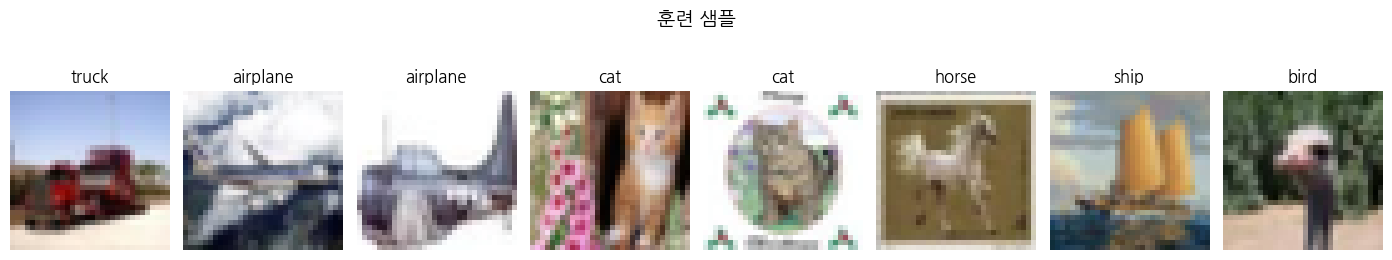

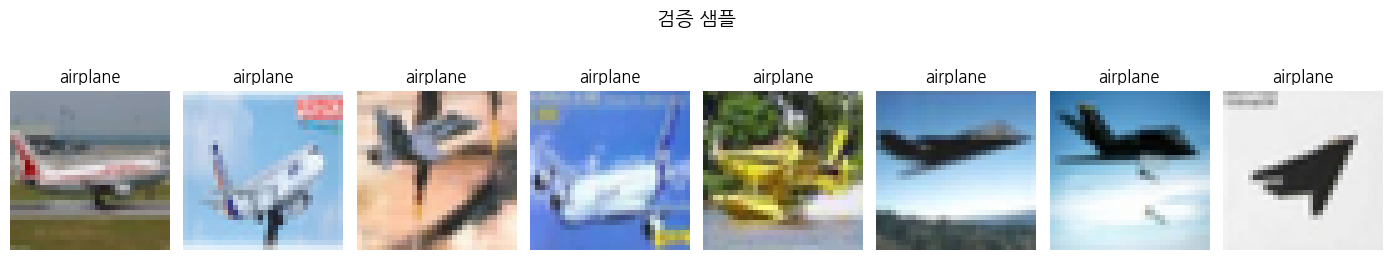

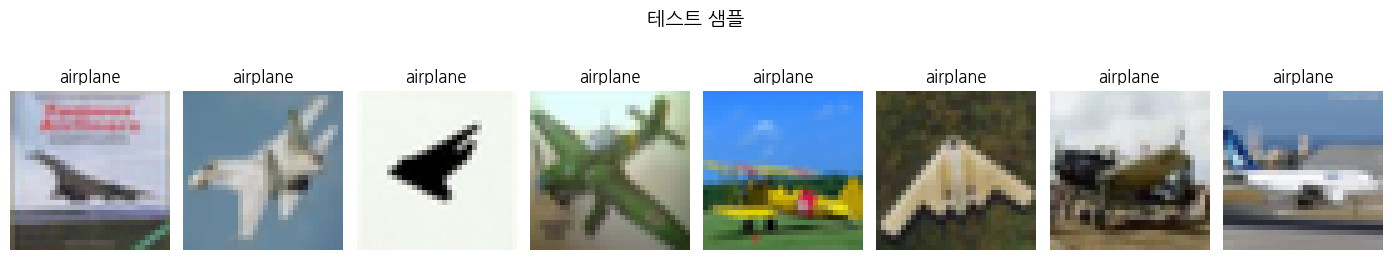

In [3]:
%run "01_dataset_dataloader.ipynb"

##### 임포트

In [4]:
import torch
import torch.nn as nn

##### Device 설정

In [5]:
# Colab에서는 CUDA, Apple Silicon Mac에서는 MPS, 그 외에는 CPU 사용
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"사용 장치: {device}")

사용 장치: cuda


##### 이미지 분류 모델 정의 (GAP 적용)

In [6]:
class Cifar10Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        # ------------------------------------------------------------------
        # Conv Block 1
        # 1) Conv: 입력 3채널(RGB) → 출력 32채널 (저수준 특징 추출)
        #   - in_channels=3: RGB 이미지의 3개 채널(빨강, 초록, 파랑)
        #   - out_channels=32: 학습할 필터(커널)의 개수.
        #     필터 하나가 feature map 하나를 만들어내므로, out_channels=32이면 feature map도 32장이 됨
        #   - kernel_size=3: 3×3 필터로 지역적 특징(엣지, 색상 등) 추출
        #   - padding=1: 출력 feature map 크기를 입력과 동일하게 유지(32×32)
        # 2) ReLU: 음수값을 0으로 제거해 비선형성 추가
        # 3) MaxPool2d: 2×2 영역에서 최댓값만 남겨 feature map을 절반으로 축소
        # ------------------------------------------------------------------
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32×32 → 16×16 (height, width)
        )

        # ------------------------------------------------------------------
        # Conv Block 2
        # 1) Conv2d: 32채널 → 64채널 (중간 수준 특징 추출)
        # 2) ReLU: 음수값을 0으로 제거해 비선형성 추가
        # 3) MaxPool2d: 2×2 영역에서 최댓값만 남겨 feature map을 절반으로 축소
        # ------------------------------------------------------------------
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16×16 → 8×8 (height, width)
        )

        # ------------------------------------------------------------------
        # Conv Block 3
        # 1) Conv2d: 64채널 → 128채널 (고수준 추상 특징 추출)
        # 2) ReLU: 음수값을 0으로 제거해 비선형성 추가
        # 3) MaxPool2d: 2×2 영역에서 최댓값만 남겨 feature map을 절반으로 축소
        # ------------------------------------------------------------------
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8×8 → 4×4 (height, width)
        )

        # ------------------------------------------------------------------
        # Classifier (GAP 방식)
        # 1) AdaptiveAvgPool2d(1): Global Average Pooling (GAP)
        #    - 피처맵(4×4)을 평균값 하나로 압축
        #    - 출력 shape: (batch, 128, 4, 4) → (batch, 128, 1, 1)
        # 2) Flatten: (batch, 128, 1, 1) → (batch, 128)
        # 3) Linear(128 → 10): 128개 채널 특징을 10개 클래스 점수(logit)로 변환하는 완전연결층(FC)
        # ------------------------------------------------------------------
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),    # (batch, 128, 4, 4) → (batch, 128, 1, 1)
            nn.Flatten(),               # (batch, 128, 1, 1) → (batch, 128)
            nn.Linear(128, 10),         # (batch, 10)
        )

    def forward(self, x):
        # 입력 x: (batch, 3, 32, 32)
        x = self.conv_block1(x)   # (batch, 32, 16, 16)
        x = self.conv_block2(x)   # (batch, 64, 8, 8)
        x = self.conv_block3(x)   # (batch, 128, 4, 4)
        x = self.classifier(x)    # GAP → Flatten → FC → (batch, 10)
        return x

##### 모델 생성 및 파라미터 수 확인

In [7]:
model = Cifar10Classifier().to(device)
print(model)

# 전체 파라미터 수: 모델이 얼마나 큰지 나타냄
total_params = sum(p.numel() for p in model.parameters())

# 학습 가능 파라미터 수: requires_grad=True인 것만 카운트 (freeze된 층 제외)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n전체 파라미터 수     : {total_params:,}")
print(f"학습 가능 파라미터 수: {trainable_params:,}")

Cifar10Classifier(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

전체 파라미터 수     : 94,538
학습 가능 파라미터 수: 94,538


##### 모델 동작 확인

In [ ]:
# CIFAR-10 입력 크기에 맞는 더미 데이터 생성: batch=1, 채널=3(RGB), 32×32
dummy_input = torch.zeros(1, 3, 32, 32).to(device)

# 순전파 실행 — 실제 학습 없이 shape만 확인
# - 내부적으로 nn.Module.__call__() → forward() 호출
output = model(dummy_input)
print(f"입력 shape : {dummy_input.shape}")   # (1, 3, 32, 32)
print(f"출력 shape : {output.shape}")        # (1, 10) ← 10개 클래스 점수

# 각 클래스에 대한 점수(logit) 중 가장 높은 인덱스를 예측 클래스로 결정
predicted_idx = output.argmax(dim=1).item()
print(f"\n예측 클래스 번호: {predicted_idx}")

# train_dataset.classes: ImageFolder가 폴더명에서 자동으로 추출한 클래스 이름 리스트
print(f"예측 클래스 이름: {train_dataset.classes[predicted_idx]}")
